# IMPORTING REQUIRED LIBRARIES

Required libraries copy pasted from Tanmay's example.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-06-19 20:30:00.642167: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781901000.828846      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781901000.883118      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781901001.343517      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781901001.343565      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781901001.343568      22 computation_placer.cc:177] computation placer alr

# THE CATEGORIES OF FACE EXPRESSIONS

In [2]:
# We make the file path by copying the main directory's file path from the input window, and adding the required
#additional file paths to extract the total file path. This is because I am unable to copy the whole file path of
#the train and validation directly. This is same as in Tanmay's.

BASE_DIR = '/kaggle/input/datasets/jonathanoheix/face-expression-recognition-dataset/'
TRAIN_DIR  = os.path.join(BASE_DIR, 'images',  'train')
TEST_DIR  = os.path.join(BASE_DIR, 'images',  'validation')
CLASSES = sorted(os.listdir(TRAIN_DIR))
print(CLASSES)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


We print the classes available (in a sorted dictionary type of way) to cross check whether every class is included or not.

Now, we would like to see an example under each category. So, we kinda "plot" it. There are 7 sub-categories. We would like to see each of them. So plotting them in a 2x4 matrix suits, with one of the box empty. The rest of the code remains similar to Tanmay's. We basically show the first picture in our input directory under each category under train.

We set up our plotting plane -> for each class, access the first pic -> convert bgr to rgb format because apparently that's how it is saved, and we will get wrong colors -> show the image along with the respective class -> turn off the axis because it's not a graph we are plotting -> remove the last 8th plot box -> show the final grid of pics.

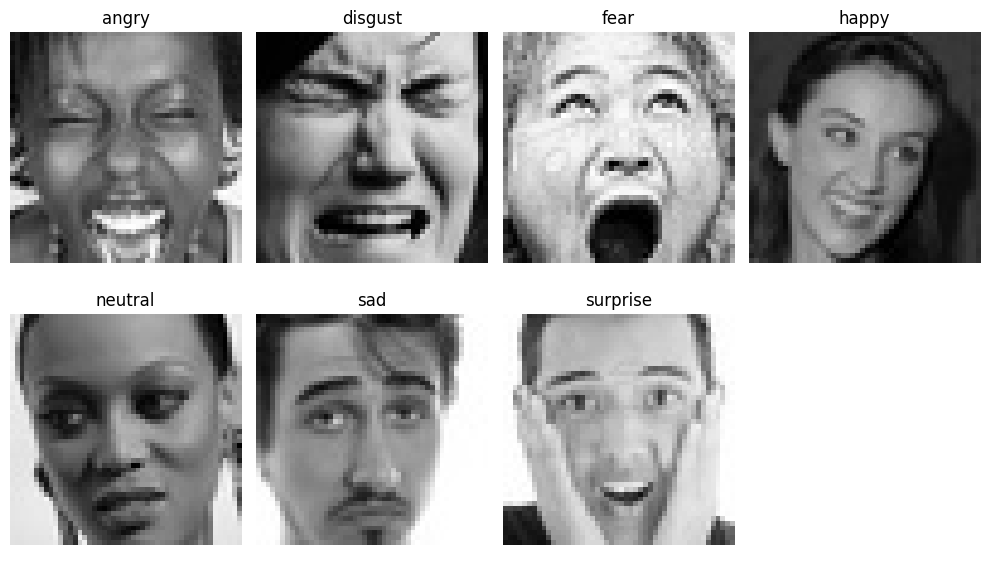

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(10, 6))
for ax, cls in zip(axes.flat, CLASSES):
    img_path = os.path.join(TRAIN_DIR, cls, os.listdir(os.path.join(TRAIN_DIR, cls))[0])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')

# Turn off the axis for the remaining empty 8th subplot
axes.flat[-1].axis('off')

plt.tight_layout()
plt.show()

# LOAD & RESIZE IMAGES and NORMALIZE & ENCODE LABELS

Same as Tanmay's code. 

We see that the available images are in greyscale, i.e., there is only 1 parameter involved, and not 3 like the RGB ones. So, we remove the RGB stuff used in the original code, and use 1 parameter.

We make a function which loads data from the directory. We initialize empty lists for the labels and their corresponding labels. We load the directory for each category, and use "IMREAD_GREYSCALE" to load the greyscale images and "read" them. We make the pic and the label arrays for our model to train on.

In [4]:
IMG_SIZE = 64

def load_data(directory):
    images, labels = [], []
    for cls in CLASSES:
        folder = os.path.join(directory, cls)
        for fname in os.listdir(folder):
            
            #Read image as grayscale using cv2.IMREAD_GRAYSCALE
            img = cv2.imread(os.path.join(folder, fname), cv2.IMREAD_GRAYSCALE)
            
            #Measure to prevent code crashing due to improper loading
            if img is None:
                continue
            
            #Resizing and appending the img data & class remains the same
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            images.append(img)
            labels.append(cls)
    return np.array(images), np.array(labels)

#The train and test arrays on which the model will train
X_train_raw, y_train_raw = load_data(TRAIN_DIR)
X_test_raw,  y_test_raw  = load_data(TEST_DIR)

#Add/"expand" the missing channel dimension so it becomes (64, 64, 1) instead of just (64, 64)
#We also "normalize", like in Tanmay's code
X_train = np.expand_dims(X_train_raw, axis=-1) / 255.0
X_test  = np.expand_dims(X_test_raw, axis=-1) / 255.0


le = LabelEncoder() #map disstinct text categories to unique integers starting from 0

#We map the categories to unique numbers, say angry -> 0, happy -> 1, sad -> 2 and so on
#Also, we convert our labels "angry", "sad", etc to 0, 2, etc accordingly
#"Fit" part achieves the mapping
#"Transform" part achieves the conversion
y_train = to_categorical(le.fit_transform(y_train_raw))

#Since, we would like to use the same mapping system, we don't use "fit_transform", but only transform
y_test  = to_categorical(le.transform(y_test_raw))

#We print the original classes as text
print("Classes:", le.classes_)

#Gives the size of each of the arrays
#X_train: (28821, 64, 64, 1) -> there're 28821 entries of size 64x64, and another additional dimension 1 for the greyscale value 
# (it was 3 in RGB)
#y_train: (28821, 7) -> there're 28821 entries (should be the same) and there are 7 possible categories, hence 7
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test:",  X_test.shape,  "| y_test:",  y_test.shape)

Classes: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprise']
X_train: (28821, 64, 64, 1) | y_train: (28821, 7)
X_test: (7066, 64, 64, 1) | y_test: (7066, 7)


# BUILDING THE CNN

*Same code as Tanmay's, but keeping in mind the fact that we used greyscale and not RGB. So, input_shape is (64, 64, 1) instead of (64, 64, 3).* Let's try to understand what's happening.

1. **The Convolutional Blocks (The Feature Extractors)**
The model uses 4 distinct blocks to analyze the image. Each block zooms out a bit more than the last to look at the bigger picture:
    * Block 1 (Basic Details): This scans the raw pixels to look for tiny, simple things like sharp lines, bright edges, or small shadows.
    * Block 2 (Shapes & Outlines): It combines those lines to recognize simple facial geometry—like the curve of an eyebrow, the roundness of an eye, or the straight edge of a nose.
    * Block 3 (Facial Structures): It combines the shapes to start seeing actual facial parts. It recognizes things like "that looks like an upturned mouth" or "those look like wide-open eyes."
    * Block 4 (High-Level Concepts): This looks at the entire layout of the face to recognize complex abstract patterns, like how wrinkled a forehead is or how pulled back a jaw is.


2. **The Internal Mechanics of Each Block**
Inside every single one of those blocks, three teamwork components are working together:
    * Conv2D: This is the magnifying glass. It slides across the image to search for visual features.
    * BatchNormalization: This is the stabilizer. It cleans up data scaling mid-flight so that the network doesn't become mathematically unstable or take too long to learn.
    * MaxPooling2D: This shrinks the image size by half, by taking the max of non-overlapping 2x2 grids. It throws away useless, repetitive pixel data and keeps only the most prominent, important details. This keeps your notebook from running out of memory.
    * Dropout: This randomly "turns off" a percentage of neurons (like 20% (0.2) or 40% (0.4)) during training. It forces the network to avoid relying on a single trick to guess the emotion, making it much more robust.


3. **The Classification Head (The Decision Maker)**
Once the blocks are done processing, the data is handed off to the final section:
    * Flatten(): At this point, the data is still structured like a tiny, deeply layered 3D image map. Flatten() squashes it into a single, long 1D list of numbers so a standard neural network can read it.
    * Dense(512): This is a massive brain layer with 512 smart connection points. It weighs all the features found by the convolutional blocks (e.g., if wide eyes = true AND downturned mouth = true...).
    * Dense(len(CLASSES), activation='softmax'): This is the final output layer. It outputs a list of 7 percentage probabilities (one for each of the emotions). The emotion with the highest percentage is the model's official prediction. The softmax function ensures that the returned value is between 0 to 1.

In [5]:
model = Sequential([
    
    # Block 1: Basic Features
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    BatchNormalization(),
    # 32 = The number of different visual features (like edges or lines) the layer searches for. This increases with complexity 
    # in the next blocks.
    # (3, 3) = The pixel size of the small sliding window used to scan the image.
    # activation='relu' = Keeps positive structural features and throws away useless negative values (turns them to 0).
    # padding ='same' = Adds a ghost border around the image so the edges don't shrink during the scan -> mxn remains mxn matrix.

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.2), # Dropout to prevent early overfitting, how? 

    # Dropout randomly "turns off" a percentage of neurons during each training step.
    # This breaks dependency on specific dominant neurons, forcing the entire network to learn features.
    # It trains the whole network part by part, and at the end, every neuron plays a role in identifying the emotion.
    # This reduces overfitting caused by a potential dominant neuron.
    
    # Block 2: Mid-level Features (Edges/Shapes)
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.3),

    # Block 3: Complex Features (Parts of the face)
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.4),

    # Block 4: Deep Features (High-level abstract patterns)
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.4),

    # Classification Block
    Flatten(),
    Dense(512, activation='relu'), # Increased from 256 to handle the extra depth
    # More layers gave your model a more powerful pair of eyes. Increasing the Dense layer to 512 gives it a bigger brain capacity 
    # to process everything those eyes are seeing. We are trying to prevent any potential bottlenecks in information processing
    # and trying to ensure a smooth operation.
    BatchNormalization(),
    Dropout(0.5), # Stronger dropout right before the final decision, as overfitting risk is apparently highest here
    Dense(len(CLASSES), activation='softmax')
])

model.summary() # Provides a text-based blueprint of your neural network

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1781901331.288237      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781901331.294263      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,278,823 (12.51 MB)

 Trainable params: 3,275,879 (12.50 MB)

 Non-trainable params: 2,944 (11.50 KB)

# DATA AUGMENTATION

Same as Tanmay's.

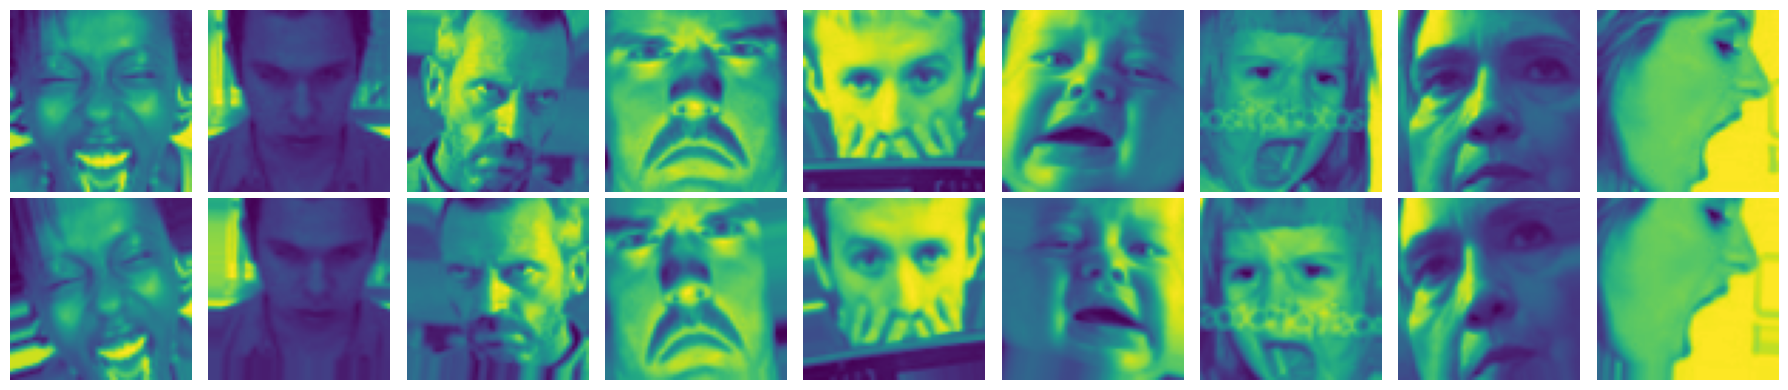

In [6]:
datagen = ImageDataGenerator(
    rotation_range=15, # randomly tilts the face up to 15 degrees left or right
    width_shift_range=0.1,
    height_shift_range=0.1,
    # shifts the face slightly off-center (up to 10% horizontally or vertically)
    horizontal_flip=True, # randomly mirrors the image horizontally
    zoom_range=0.1 # randomly zooms in or out by up to 10%
)

sample_batch = X_train[:9] # grabs the first 9 original images from your training set
aug_iter = datagen.flow(sample_batch, batch_size=9, shuffle=False)
# passes those 9 images through your simulator, shuffle=False to prevent mismatch of picture & corresponding labels
aug_batch = next(aug_iter)
# gather the image info from the aug_iter iterable created

# Grid of 2 rows and 9 columns, 1st row with the original, 2nd row with the edited
fig, axes = plt.subplots(2, 9, figsize=(18, 4))
for i in range(9):
    axes[0, i].imshow(sample_batch[i])
    axes[0, i].axis('off')
    axes[1, i].imshow(np.clip(aug_batch[i], 0, 1))
    axes[1, i].axis('off')
axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Augmented", fontsize=10)
plt.tight_layout()
plt.show()

# COMPILATION & TRAINING

*Same as Tanmay's*

This block of code handles the **compilation** (setting up the rules) and the actual **training** (the learning process) of your model. Think of this stage as sending your neural network to a grueling 50-day boot camp (`epochs=50`), but you are hiring **two smart robotic coaches** (`callbacks`) to monitor its health so it doesn't over-exhaust itself or get stuck.

Here is the easy breakdown of what each part is doing:

### 1. The Compilation Rulebook (`model.compile`)

Before the model can look at a single picture, you have to tell it how it will be judged and how it should fix its mistakes:

* **`optimizer='adam'` (The Smart Auto-Tweak):** Adam is like a highly efficient mechanic. After every batch of images, it calculates how far off the model's guesses were and tweaks the internal 3.2 million settings (weights) just the right amount so the model does better next time.
* **`loss='categorical_crossentropy'` (The Penalty Score):** This is the grading system. If the model is 99% confident a face is "happy" when it's actually "sad", this function hands it a massive mathematical penalty. The goal of training is to get this loss score as close to zero as possible.
* **`metrics=['accuracy']` (The Scoreboard):** This simply prints out a human-readable percentage during training (e.g., *"The model is currently guessing 58% of the faces correctly"*).

### 2. The Robotic Coaches (`callbacks`)

Instead of blindly forcing the model to run for all 50 cycles (epochs), you’ve created two safety guards to look over its shoulder:

* **Coach 1: `EarlyStopping` (The Fatigue Preventer)**
* It monitors the validation loss (the test score). If the model trains for **7 days straight (`patience=7`)** and its test scores stop getting better, this coach yells, *"Stop! We are done training!"* * It automatically rolls back the model's brain to the exact day it achieved its best performance (`restore_best_weights=True`). This stops the model from wasting time and overfitting.

* **Coach 2: `ReduceLROnPlateau` (The Fine-Tuner)**
* At the start, the model makes massive, aggressive leaps to learn features. But as it gets closer to perfection, big leaps can make it overshoot the target.
* If the test score stays stuck for **3 days (`patience=3`)**, this coach cuts the learning speed by 80% (`factor=0.2`). This forces the model to take tiny, careful micro-steps to carefully fine-tune its understanding of subtle facial lines.

### 3. The Boot Camp (`model.fit`)

This is where the engine starts roaring:

* **`datagen.flow(X_train, y_train, batch_size=64)`:** It feeds your training data to the model in random, augmented packs of 64 images at a time.
* **`epochs=50`:** The maximum number of complete trips through your entire dataset.
* **`validation_data=(X_test, y_test)`:** At the end of every single epoch, the model pauses and takes a pop quiz using 7,066 pristine validation images it has never seen before to prove how smart it *actually* is.

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Add callbacks to handle the deeper architecture smoothly
callbacks = [
    # Stops training if validation loss stops improving for 7 epochs; verbose=1 displays the progress bar
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    
    # Lowers learning rate if progress plateaus, helping the model fine-tune
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
]

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=callbacks
)

Epoch 1/50


I0000 00:00:1781901339.808999      70 service.cc:152] XLA service 0x7f61dc002520 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781901339.809049      70 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781901339.809054      70 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781901341.004073      70 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-19 20:35:44.627807: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-19 20:35:44.773581: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  3/451 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.1267 - loss: 3.1982   

I0000 00:00:1781901352.979783      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


394/451 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.2062 - loss: 2.4459

2026-06-19 20:36:11.246392: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-19 20:36:11.387583: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


451/451 ━━━━━━━━━━━━━━━━━━━━ 52s 72ms/step - accuracy: 0.2533 - loss: 2.1000 - val_accuracy: 0.2295 - val_loss: 1.8155 - learning_rate: 0.0010
Epoch 2/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.3696 - loss: 1.6557 - val_accuracy: 0.4393 - val_loss: 1.5050 - learning_rate: 0.0010
Epoch 3/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.4403 - loss: 1.4681 - val_accuracy: 0.5025 - val_loss: 1.3185 - learning_rate: 0.0010
Epoch 4/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.4791 - loss: 1.3545 - val_accuracy: 0.5035 - val_loss: 1.2967 - learning_rate: 0.0010
Epoch 5/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.5085 - loss: 1.2786 - val_accuracy: 0.5317 - val_loss: 1.2605 - learning_rate: 0.0010
Epoch 6/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.5281 - loss: 1.2388 - val_accuracy: 0.5572 - val_loss: 1.1654 - learning_rate: 0.0010
Epoch 7/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.5455 - loss: 1.2027

POV: YOU GET 67% ACCURACY IN BOTH THE TRAINING AND VALIDATION DATA

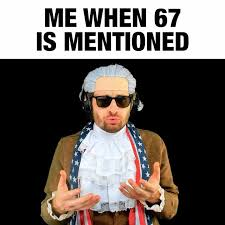

# TRAINING CURVES

Same code as Tanmay's.

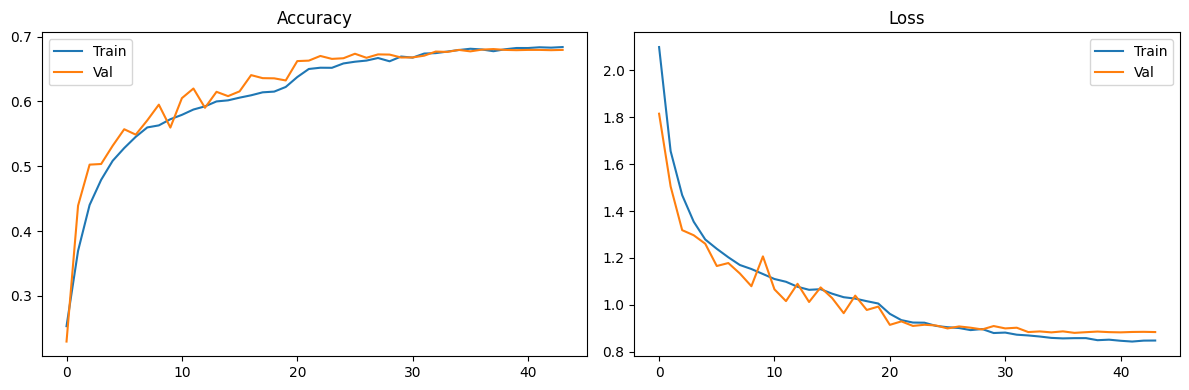

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plots training vs. validation metrics side-by-side after training finishes.
# Left Plot (axes[0]): Tracks accuracy improvement (higher is better).
# Right Plot (axes[1]): Tracks loss/error reduction (lower is better).
# Used to visually detect if the model is learning well or overfitting.

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# CONFUSON MATRIX 

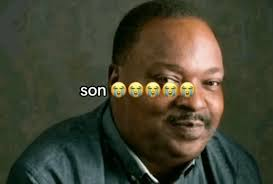

221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


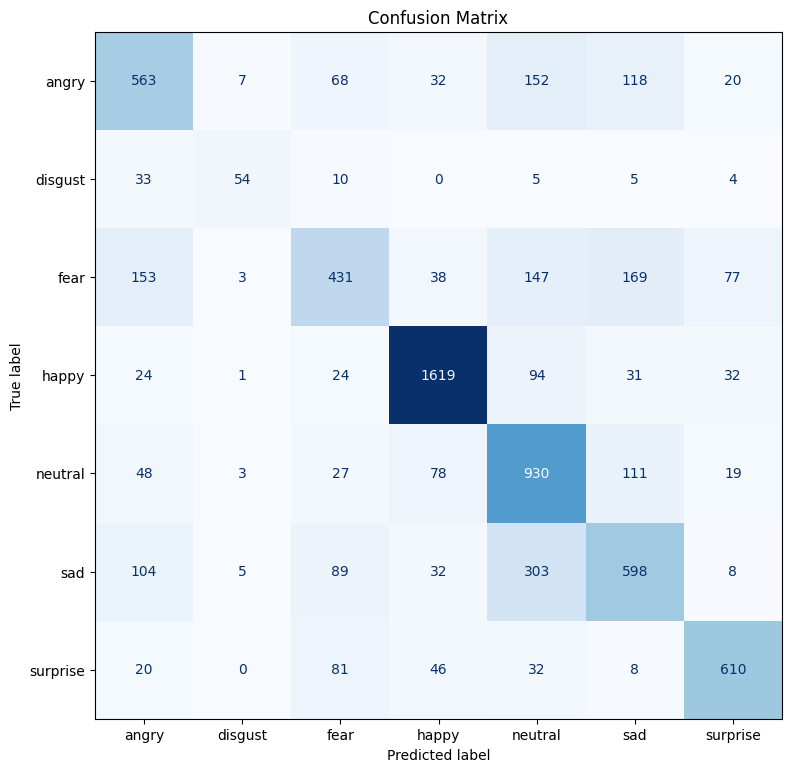

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Same as Tanmay's.
# Generates a 7x7 evaluation grid comparing true emotions against predicted emotions.
# Diagonal squares show correct predictions; off-diagonal squares reveal specific errors.
# Essential for seeing exactly which emotions the model mixes up (e.g., mistaking Fear for Surprise).

# Feeds the validation images to the trained model to get our probabilities
y_pred = model.predict(X_test)

# Looks at the 7 probabilities -> takes highest index number -> convert back to their text names -> checks and stores if right or wrong
cm = confusion_matrix(y_test_raw, le.inverse_transform(np.argmax(y_pred, axis=1)))

# Pairs the raw 7x7 numeric grid with the actual emotion labels, so it knows what to print on x & y axes
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(8, 8))

# Draws the grid onto the canvas using a blue color theme and hides the side scale bar -> colorbar=False
# Squares with higher numbers automatically turn dark blue
disp.plot(ax=ax, colorbar=False, cmap='Blues')

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# PREDICTION ON 10 IMAGES

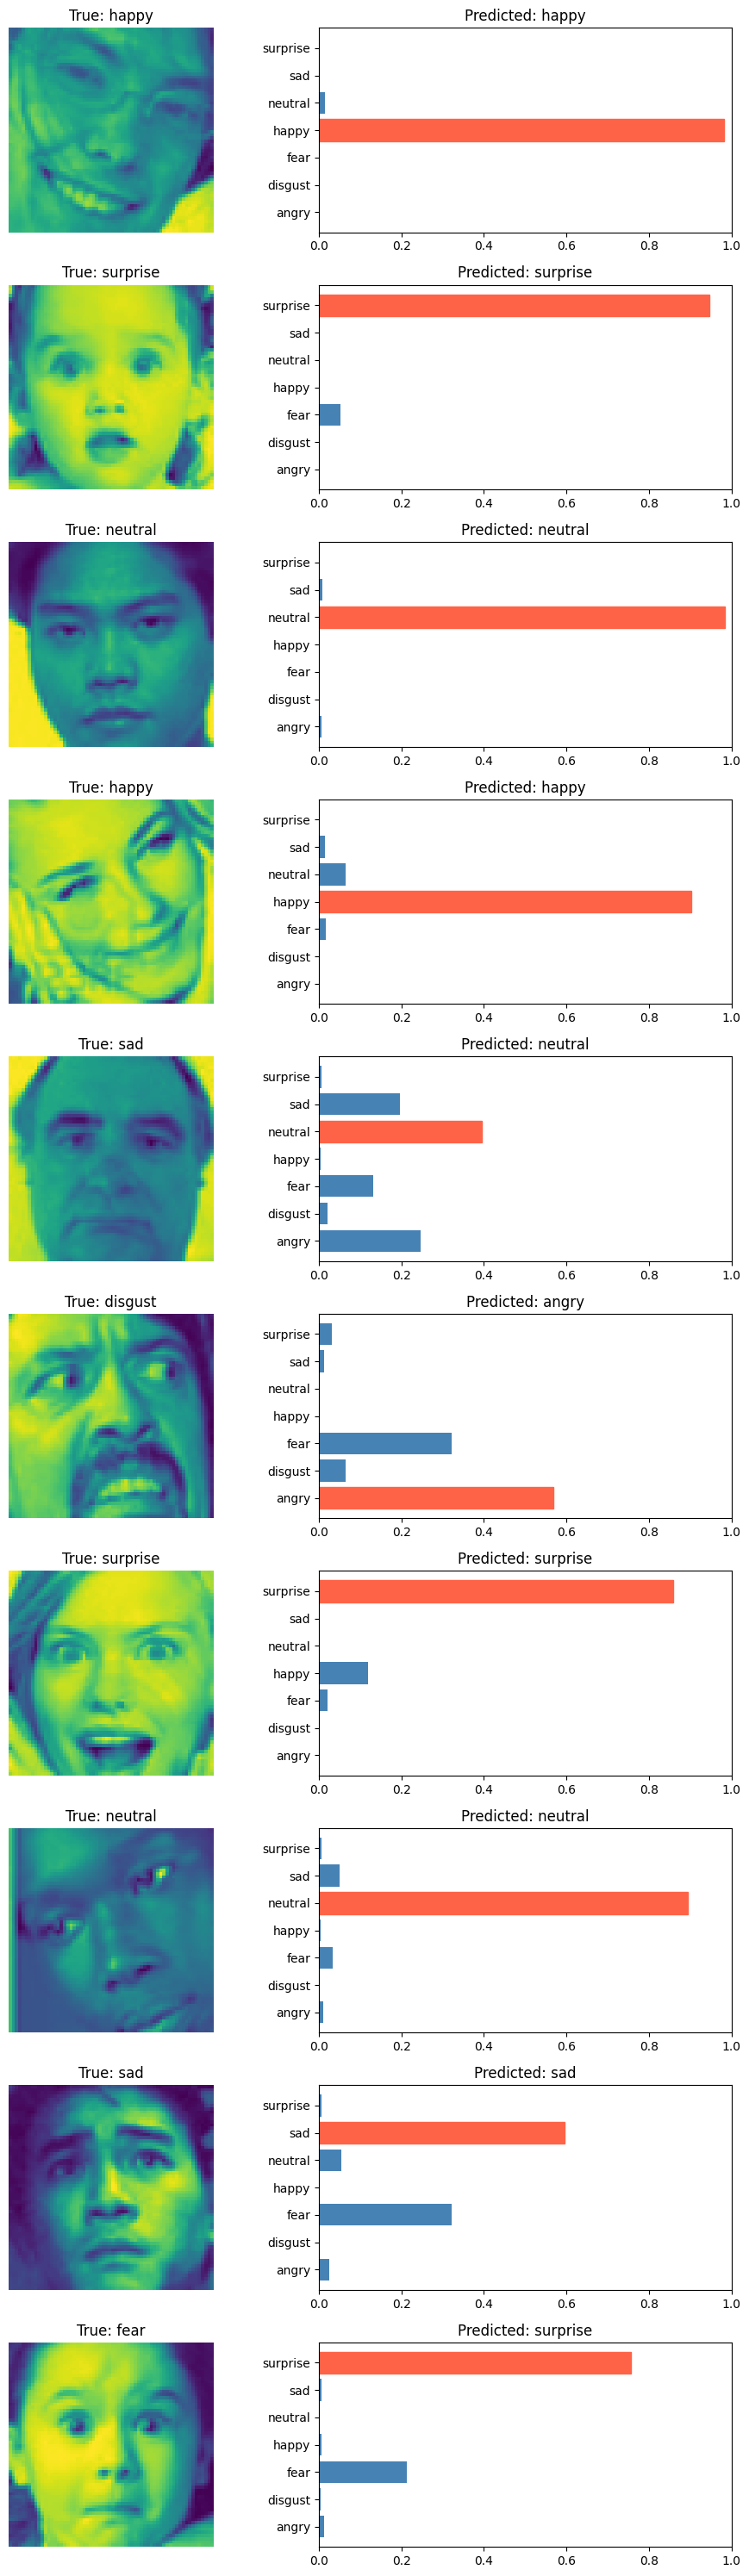

In [10]:
# Feeding 10 random images from validation dataset
n = 10
indices = np.random.randint(len(X_test), size=n)

# Setup a vertical grid with 10 rows and 2 columns (left for face, right for bar chart)
fig, axes = plt.subplots(n, 2, figsize=(10, n * 3))

# Loop through each of the 10 chosen random images
for row, idx in enumerate(indices):
    img = X_test[idx]

    # Format image to match model input shape, predict, and get the 7 emotion probabilities
    probs = model.predict(img[np.newaxis, ...], verbose=0)[0]
    # Why the [0]? It's because we are passing a list of 1 element. Apparently, Keras models are built to predict in a batch, but since 
    # we are giving only 1 image for processing at a time, we provide it with a list of a single element.
    # Hence, it returns the output as a list of a single element, say -> [ [0.01, 0.02, 0.85, 0.02, 0.0, 0.10, 0.0] ]
    # To access the only element, we do list[0]
    # verbose=0 -> prevent cluttering outputs by turning off extra text outputs, eg, a seperate progress bar animation

    # Left Column: Display the actual grayscale face image and title it with the true label
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"True: {y_test_raw[idx]}")
    axes[row, 0].axis('off')

    # Right Column: Create a horizontal bar chart showing the probability outcome for all 7 classes
    bars = axes[row, 1].barh(le.classes_, probs, color='steelblue')
    bars[np.argmax(probs)].set_color('tomato')
    axes[row, 1].set_xlim(0, 1)
    axes[row, 1].set_title(f"Predicted: {le.classes_[np.argmax(probs)]}")

plt.tight_layout()
plt.show()

# REAL-LIFE TESTING

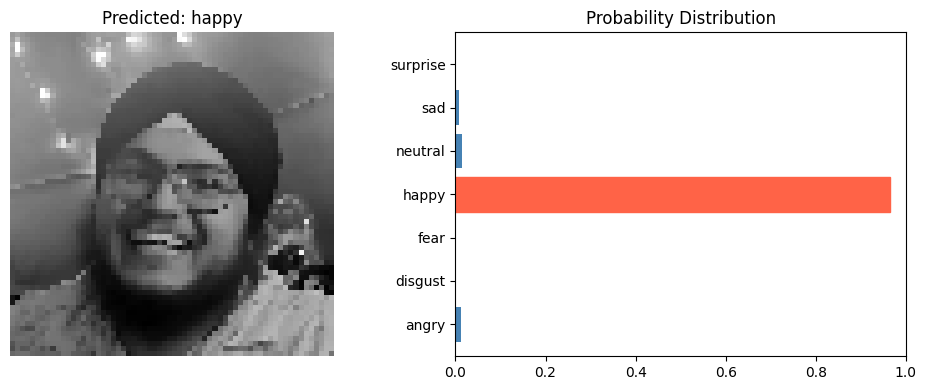

In [11]:
custom_img_path = '/kaggle/input/datasets/sayantanmondal1317/real-life/Harpuneet.jpeg'

# Load the image in grayscale
raw_img = cv2.imread(custom_img_path, cv2.IMREAD_GRAYSCALE)

# Measure to prevent code crashing due to improper loading
if raw_img is None:
    print("Error: Could not load the image. Double-check your file path!")
else:
    
    resized_img = cv2.resize(raw_img, (64, 64))
    normalized_img = resized_img / 255.0

    # Format image -> (1, 64, 64, 1)
    input_tensor = normalized_img[np.newaxis, ..., np.newaxis]

    # Get probabilities and set up plotting grid
    custom_probs = model.predict(input_tensor, verbose=0)[0]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # 8. Left Column: Display the processed grayscale face image and title it with the prediction
    axes[0].imshow(normalized_img, cmap='gray')
    axes[0].set_title(f"Predicted: {le.classes_[np.argmax(custom_probs)]}")
    axes[0].axis('off')

    # 9. Right Column: Create a horizontal bar chart showing the probability outcome for all 7 classes
    bars = axes[1].barh(le.classes_, custom_probs, color='steelblue')
    
    # 10. Highlight the model's top prediction bar in a red/tomato color
    bars[np.argmax(custom_probs)].set_color('tomato')
    axes[1].set_xlim(0, 1) # cap the probability axis at 100% (1.0)
    axes[1].set_title("Probability Distribution")

    plt.tight_layout()
    plt.show()